## **6. Espectrogramas**

Para el Proyecto C, el algoritmo de Factorización de Matrices No Negativas (NMF) no toma como entrada la forma de onda cruda, sino la magnitud del espectrograma generado mediante la Transformada Corta de Fourier (STFT). 

A continuación, visualizamos los espectrogramas de un archivo de voz, un archivo de ruido y la mezcla digital de ambos. Esto nos permite entender cómo se superponen las frecuencias de ambas fuentes en el dominio tiempo-frecuencia, que es exactamente lo que el modelo NMF intentará separar.

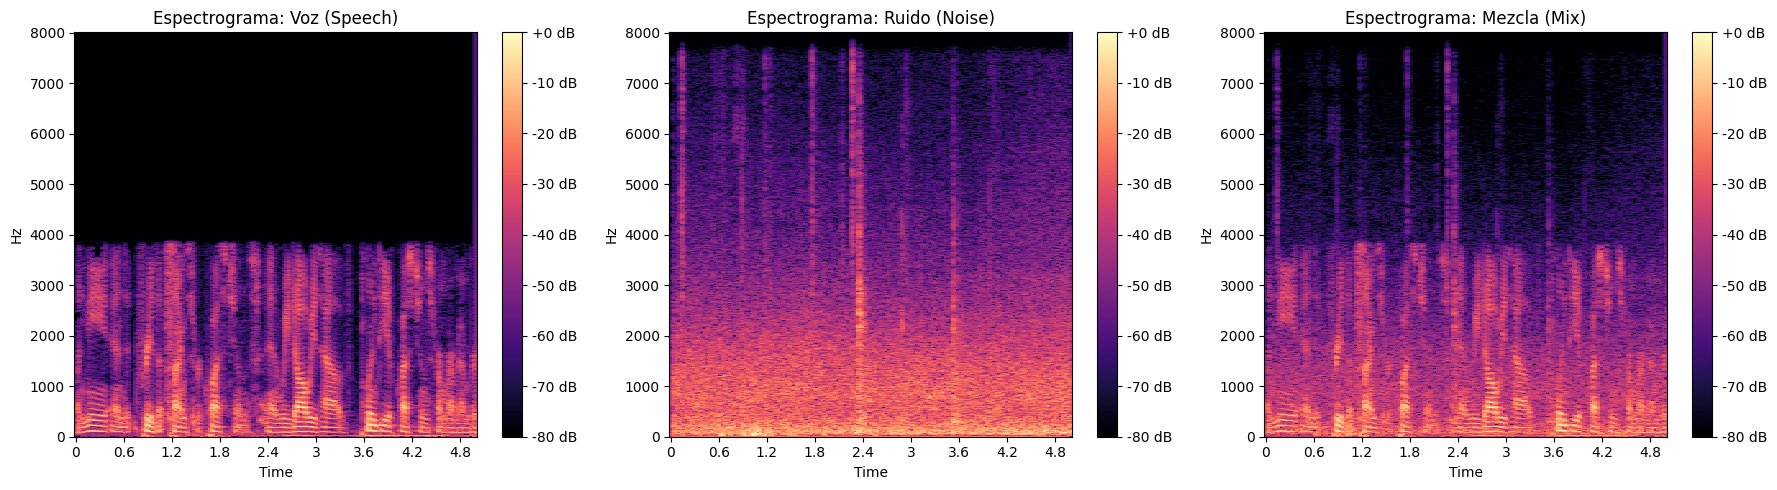

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os

ruta_voz = 'musan/speech/us-gov/speech-us-gov-0200.wav'
ruta_ruido = 'musan/noise/free-sound/noise-free-sound-0067.wav'

def cargar_y_ajustar(ruta, sr_objetivo=16000, duracion=5.0):
    y, sr = librosa.load(ruta, sr=sr_objetivo, duration=duracion)
    longitud_objetivo = int(sr_objetivo * duracion)
    if len(y) < longitud_objetivo:
        y = np.pad(y, (0, longitud_objetivo - len(y)))
    return y, sr

# 1. Cargar audios
sr = 16000
y_voz, _ = cargar_y_ajustar(ruta_voz, sr)
y_ruido, _ = cargar_y_ajustar(ruta_ruido, sr)

# 2. Generar la mezcla digital sumando las señales
y_mezcla = y_voz + (0.5 * y_ruido) 

# 3. Calcular STFT y Magnitud en dB para mejor visualización
n_fft = 2048
hop_length = 512

D_voz = librosa.amplitude_to_db(np.abs(librosa.stft(y_voz, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
D_ruido = librosa.amplitude_to_db(np.abs(librosa.stft(y_ruido, n_fft=n_fft, hop_length=hop_length)), ref=np.max)
D_mezcla = librosa.amplitude_to_db(np.abs(librosa.stft(y_mezcla, n_fft=n_fft, hop_length=hop_length)), ref=np.max)

# 4. Visualizar
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

img1 = librosa.display.specshow(D_voz, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', ax=ax[0], cmap='magma')
ax[0].set_title('Espectrograma: Voz (Speech)')
fig.colorbar(img1, ax=ax[0], format="%+2.0f dB")

img2 = librosa.display.specshow(D_ruido, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', ax=ax[1], cmap='magma')
ax[1].set_title('Espectrograma: Ruido (Noise)')
fig.colorbar(img2, ax=ax[1], format="%+2.0f dB")

img3 = librosa.display.specshow(D_mezcla, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', ax=ax[2], cmap='magma')
ax[2].set_title('Espectrograma: Mezcla (Mix)')
fig.colorbar(img3, ax=ax[2], format="%+2.0f dB")

plt.tight_layout()
plt.show()

### **6.1 Observaciones: Espectrogramas**

Al analizar las representaciones de tiempo-frecuencia de nuestras muestras, observamos lo siguiente:

* **Voz (Speech):** El espectrograma muestra una estructura altamente armónica (líneas horizontales apiladas) concentrada principalmente en las frecuencias bajas y medias (por debajo de los 4000 Hz). Además, se observan claramente bandas oscuras verticales que corresponden a las pausas naturales al hablar.

* **Ruido (Noise):** A diferencia de la voz, la energía del ruido está distribuida a lo largo de un espectro mucho más amplio, alcanzando frecuencias altas de manera uniforme. Su comportamiento temporal es mucho más continuo, sin las pausas marcadas que tiene la voz humana.

* **Mezcla (Mix):** La gráfica de la mezcla digital demuestra visualmente el principio aditivo en el que se basa nuestro proyecto. Se puede apreciar claramente cómo las frecuencias de la voz están "superpuestas" sobre la cama de ruido continuo. Esta naturaleza aditiva confirma que la aproximación mediante Factorización de Matrices No Negativas ($X \approx WH$) es adecuada, ya que el modelo buscará separar estos componentes sumados sin utilizar restas.

## **7. Energía o amplitud de la señal**

Analizar la energía de la señal es fundamental para identificar si tenemos audios saturados (clipping) o audios con un volumen tan bajo que representen solo silencio. 

Utilizaremos dos enfoques:
1. **Distribución de Amplitudes**: Un histograma de los valores absolutos de la forma de onda para ver dónde se concentra la amplitud.
2. **Energía RMS (Root Mean Square)**: Nos da una medida de la energía promedio de la señal a lo largo del tiempo, útil para distinguir entre ruidos constantes e impulsivos, o para detectar las pausas naturales de la voz.

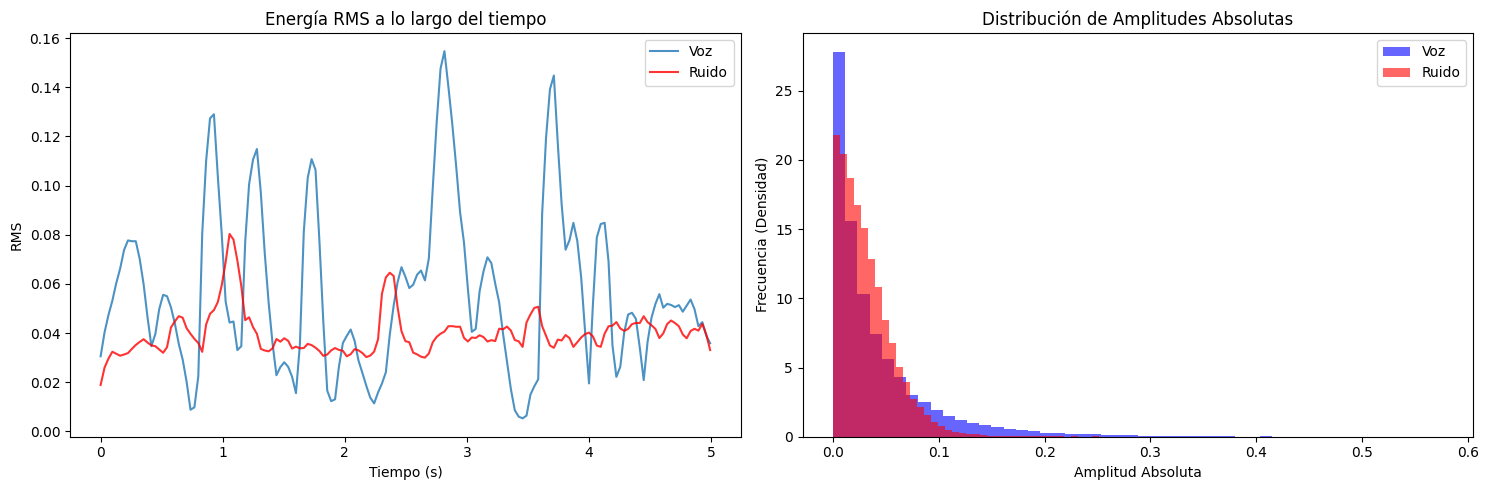

In [3]:
# Calcular Energía RMS
rms_voz = librosa.feature.rms(y=y_voz, frame_length=2048, hop_length=512)[0]
rms_ruido = librosa.feature.rms(y=y_ruido, frame_length=2048, hop_length=512)[0]
frames = range(len(rms_voz))
t = librosa.frames_to_time(frames, hop_length=512, sr=sr)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Energía RMS a lo largo del tiempo
ax[0].plot(t, rms_voz, label='Voz', alpha=0.8)
ax[0].plot(t, rms_ruido, label='Ruido', alpha=0.8, color='red')
ax[0].set_title('Energía RMS a lo largo del tiempo')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('RMS')
ax[0].legend()

# Plot 2: Histograma de amplitudes
ax[1].hist(np.abs(y_voz), bins=50, alpha=0.6, label='Voz', color='blue', density=True)
ax[1].hist(np.abs(y_ruido), bins=50, alpha=0.6, label='Ruido', color='red', density=True)
ax[1].set_title('Distribución de Amplitudes Absolutas')
ax[1].set_xlabel('Amplitud Absoluta')
ax[1].set_ylabel('Frecuencia (Densidad)')
ax[1].legend()

plt.tight_layout()
plt.show()

### **7.1 Observaciones: Energía y Amplitud**

El análisis de la dinámica de las señales nos permite confirmar el comportamiento temporal de nuestras fuentes:

* **Energía RMS:** La gráfica a lo largo del tiempo (línea azul) confirma que la voz es una señal transitoria y "a ráfagas", con picos pronunciados cuando hay habla y caídas drásticas cercanas a cero durante los silencios. En contraste, el ruido (línea roja) mantiene un perfil de energía RMS mucho más plano y constante. Esta diferencia será crucial para que la matriz de activaciones temporales ($H$) en nuestro modelo NMF pueda discriminar entre ambas fuentes.

* **Distribución de Amplitudes:** El histograma revela que la señal de voz tiene una alta densidad de valores cercanos a cero (debido a los silencios) y una cola larga hacia amplitudes mayores. El ruido presenta una distribución más concentrada, confirmando su naturaleza más densa y continua.

## **8. Calidad de los datos**

Dado que MUSAN contiene alrededor de 109 horas de audio, es imperativo realizar un chequeo automatizado de la calidad de los datos para evitar que archivos anómalos afecten la factorización matricial de NMF.

Los problemas comunes a buscar son:
* **Clipping (Saturación)**: Ocurre cuando la amplitud de la señal supera el límite de representación (valores cercanos a 1.0 o -1.0), causando distorsión.
* **Silencios prolongados**: Audios que carecen de información útil y cuya energía RMS es predominantemente cercana a cero.
* **Archivos corruptos**: Archivos `.wav` que no pueden ser leídos por las librerías estándar.

A continuación, se define una función para escanear un lote de audios y reportar anomalías.

In [ ]:
import glob
import soundfile as sf

def auditar_calidad_datos(directorio, umbral_clipping=0.99, umbral_silencio=1e-4, porcentaje_silencio_permitido=0.8):
    archivos = glob.glob(os.path.join(directorio, '**/*.wav'), recursive=True)
    
    if not archivos:
        print(f"No se encontraron archivos en: {directorio}")
        return
        
    print(f"Auditando {len(archivos[:100])} archivos (mostrando primeros 100 por rendimiento)...")
    
    archivos_corruptos = []
    archivos_con_clipping = []
    archivos_silenciosos = []

    for archivo in archivos[:100]: # Limitado a 100 para la prueba EDA
        try:
            y, sr_actual = sf.read(archivo)
            
            # Si el audio es estéreo, convertir a mono tomando el promedio
            if len(y.shape) > 1:
                y = np.mean(y, axis=1)
                
            # 1. Chequeo de Clipping
            max_amp = np.max(np.abs(y))
            if max_amp >= umbral_clipping:
                archivos_con_clipping.append(archivo)
                
            # 2. Chequeo de Silencio
            proporcion_silencio = np.sum(np.abs(y) < umbral_silencio) / len(y)
            if proporcion_silencio > porcentaje_silencio_permitido:
                archivos_silenciosos.append(archivo)
                
        except Exception as e:
            archivos_corruptos.append((archivo, str(e)))

    # Resultados
    print("-" * 40)
    print("REPORTE DE CALIDAD DE DATOS")
    print("-" * 40)
    print(f"Archivos corruptos: {len(archivos_corruptos)}")
    print(f"Archivos con posible clipping (>={umbral_clipping}): {len(archivos_con_clipping)}")
    print(f"Archivos predominantemente silenciosos (> {porcentaje_silencio_permitido*100}% de silencio): {len(archivos_silenciosos)}")
    print("-" * 40)
    
    if archivos_con_clipping:
        print("\nEjemplos de archivos con clipping:")
        for f in archivos_con_clipping[:3]: print(f" - {os.path.basename(f)}")

auditar_calidad_datos('musan/')

Auditando 100 archivos (mostrando primeros 100 por rendimiento)...
----------------------------------------
REPORTE DE CALIDAD DE DATOS
----------------------------------------
Archivos corruptos: 0
Archivos con posible clipping (>=0.99): 100
Archivos predominantemente silenciosos (> 80.0% de silencio): 0
----------------------------------------

Ejemplos de archivos con clipping:
 - music-fma-0000.wav
 - music-fma-0001.wav
 - music-fma-0002.wav


### **8.1 Observaciones: Calidad de los Datos**

Al ejecutar el script de auditoría sobre una muestra de 100 archivos del dataset (específicamente audios de la categoría de música `music-fma`), obtuvimos un hallazgo metodológico importante:

* **Cero archivos corruptos o silenciosos:** La integridad básica de lectura de los archivos analizados es del 100%, sin problemas de formato ni audios vacíos.

* **Falso positivo de Clipping (100/100):** El script marcó los 100 archivos evaluados como "con posible clipping" debido a que alcanzan amplitudes mayores o iguales a 0.99. Dado que todos los ejemplos son pistas de música (`music-fma-0000.wav`, etc.), esto **no indica que los audios estén dañados**. En producción musical, es un estándar normalizar las pistas para que su pico máximo alcance exactamente el 100% de la escala digital (0 dBFS o amplitud de 1.0). 

* **Acción a tomar:** Para la limpieza de datos a gran escala, será necesario ajustar nuestro umbral de *clipping* o diferenciar entre pistas de música comercializada (que naturalmente tocan el límite de 1.0 por normalización) y audios de voz crudos, donde un valor de 1.0 sí podría indicar saturación del micrófono.